In [23]:
import rich
import logging
import glob

import matplotlib.pyplot as plt
import time
import os
import awkward as ak
import numpy as np
import pandas as pd
from lgdo import lh5
from legendmeta import LegendMetadata
from dbetto import Props
from pygama.pargen.AoE_cal import *
from pygama.pargen.AoE_cal import CalAoE, Pol1, SigmaFit, aoe_peak
from pygama.pargen.data_cleaning import get_tcm_pulser_ids
from pygama.pargen.utils import load_data
from tqdm import tqdm

%matplotlib inline

logging.basicConfig(level=logging.INFO)
logging.getLogger('numba').setLevel(logging.INFO)
logging.getLogger('parse').setLevel(logging.INFO)

# Function

In [47]:
def single_plot(data, par, title = "xxx", cmax = 6):
        
    classifier = data[f"classifier_{par}"]
    
    plt.figure(figsize=(20,6), dpi=300)
    
    m_all = ~data["is_discharge"]
    m_pl = m_all & data["is_pulser"]
    m_ft = m_all & data["forced_trigger"]
    m_clean = m_all & ~data["forced_trigger"] & ~data["is_pulser"] & data["is_below_500keV"]
    
    mask_25_50 = (data["cuspEmax_ctc_cal"] >= 25) & (data["cuspEmax_ctc_cal"] <= 50)
    m_very_low = (
        m_all
        & ~data["forced_trigger"]
        & ~data["is_pulser"]
        & mask_25_50
    )
    
    m_above_500 = (
        m_all
        & ~data["forced_trigger"]
        & ~data["is_pulser"]
        & (data["cuspEmax_ctc_cal"] >= 500)
    )
    
    m_above_50_500 = (
        m_all
        & ~data["forced_trigger"]
        & ~data["is_pulser"]
        & (data["cuspEmax_ctc_cal"] >= 50) & (data["cuspEmax_ctc_cal"] <= 500)
    )
    
    
    
    cmin = -6
    #cmax = 1000
    bins = 500
    
    
    plt.hist(classifier[m_all & ~data["forced_trigger"] & ~data["is_pulser"] & (data["cuspEmax_ctc_cal"] >= 25)], bins=bins, range=(cmin, cmax), histtype='step', label='All >25 keV')
    #plt.hist(classifier[m_pl], bins=bins, range=(cmin, cmax), histtype='step', label='PL')
    #plt.hist(classifier[m_ft], bins=bins, range=(cmin, cmax), histtype='step', label='FT')
    plt.hist(classifier[m_above_50_500], bins=bins, range=(cmin, cmax), histtype='step', label='~PL & ~FT & 50 < <500 keV')
    plt.hist(classifier[m_very_low], bins=bins, range=(cmin, cmax), histtype='step', color = 'deepskyblue', label='~PL & ~FT & 25 < <50 keV')
    plt.hist(classifier[m_above_500], bins=bins, range=(cmin, cmax), histtype='step', label='~PL & ~FT & >500 keV')
    
    
    plt.axvspan(-25, -5, color = 'grey', alpha=0.15)
    plt.axvspan(5,cmax, color = 'grey', alpha=0.15)
    plt.xticks(range(0,1001, 50))
    plt.vlines(-5, 0, 1e5, ls = '--', color = 'grey' )
    plt.vlines(5, 0, 1e5, ls = '--', color = 'grey', label = 'Classifier CUT' )
    plt.ylabel('Counts')
    plt.title(f"{title} : r000 + r001")
    plt.xlabel(f'Classifier {par}')
    plt.yscale('log')
    plt.xlim(cmin, cmax)
    plt.legend(loc = 'upper right', fontsize = 20)

    return

In [25]:
def energy_spectrum_cut_plot(data, classifier_par):

    plt.figure(figsize=(16,6), dpi=300)

    
    ene = data['cuspEmax_ctc_cal']
    
    m_discharge = ~data["is_discharge"]
    m_pulser = data["is_pulser"]
    m_ft = data["forced_trigger"]
    m_lowE = data["is_below_500keV"]
    m_fix = data["is_HPGe"]&~data["is_muon"]
    m_classifier = data[f"is_valid_{classifier_par}"]
    
    
    CUT = len(ene[m_discharge & ~m_pulser & ~m_ft & m_fix & ~m_classifier]) * 100/ len(ene[m_discharge & ~m_pulser & ~m_ft & m_fix])
    PASS = len(ene[m_discharge & ~m_pulser & ~m_ft & m_fix & m_classifier]) * 100/ len(ene[m_discharge & ~m_pulser & ~m_ft & m_fix])
    
    emin = -1000
    emax = 6000
    bins = int((emax-emin)/10)
    
    
    plt.hist(ene[m_discharge & ~m_pulser & ~m_ft & m_fix], 
             bins = bins, 
             range=(emin, emax), 
             histtype = 'step',
             color = 'gray',
             label = f'All {len(ene[m_discharge & ~m_pulser & ~m_ft & m_fix])}'
            )
    
    plt.hist(ene[m_discharge & ~m_pulser & ~m_ft & m_fix & m_classifier], 
             bins = bins, 
             range=(emin, emax), 
             histtype = 'step',
             color = 'deepskyblue',
             label = f'is_valid_{classifier_par} {len(ene[m_discharge & ~m_pulser & ~m_ft & m_fix & m_classifier])}, PASS={PASS:.3f}%'
            )
    
    plt.hist(ene[m_discharge & ~m_pulser & ~m_ft & m_fix & ~m_classifier], 
             bins = bins, 
             range=(emin, emax), 
             histtype = 'step',
             color = 'brown',
             label = f'~is_valid_{classifier_par} {len(ene[m_discharge & ~m_pulser & ~m_ft & m_fix & ~m_classifier])}, CUT={CUT:.3f}%'
            )
    
    plt.legend(loc = 'upper right')
    plt.xlabel('Energy [keV]')
    plt.ylabel('Counts / 10 keV')
    plt.title(f'{classifier_par} cut')
    plt.xlim(emin, emax)
    plt.yscale('log')

    

# Get data

In [31]:
from pathlib import Path

folders = ["Parquet data r000", "Parquet data r001"]

for folder in folders:
    for f in Path(folder).glob("*.parquet"):
        print(f, f.stat().st_mtime)

Parquet data r000/data_ICPC_phy_ALL.parquet 1780687712.351937
Parquet data r000/data_BEGe_phy_ALL.parquet 1780688127.2272592
Parquet data r000/data_Coax_phy_ALL.parquet 1780688546.8086064
Parquet data r000/data_PPC_phy_ALL.parquet 1780689325.7202973
Parquet data r001/data_ICPC_phy_ALL.parquet 1780687838.1937087
Parquet data r001/data_BEGe_phy_ALL.parquet 1780688278.1686466
Parquet data r001/data_Coax_phy_ALL.parquet 1780687200.5005338
Parquet data r001/data_PPC_phy_ALL.parquet 1780688617.6470685


In [32]:
from pathlib import Path

for folder in folders:
    print(folder)
    print(Path(folder).resolve())

Parquet data r000
/global/u2/r/ritaferi/Low Energy QC/Baseline/Parquet data r000
Parquet data r001
/global/u2/r/ritaferi/Low Energy QC/Baseline/Parquet data r001


In [33]:
for folder in folders:
    file = Path(folder) / "data_Coax_phy_ALL.parquet"
    print(file.resolve())

/global/u2/r/ritaferi/Low Energy QC/Baseline/Parquet data r000/data_Coax_phy_ALL.parquet
/global/u2/r/ritaferi/Low Energy QC/Baseline/Parquet data r001/data_Coax_phy_ALL.parquet


In [34]:
from pathlib import Path
import pandas as pd

folders = ["Parquet data r000", "Parquet data r001"]
#folders = ["data r000"]

def load_detector(filename):
    return pd.concat(
        [pd.read_parquet(Path(folder) / filename) for folder in folders],
        ignore_index=True
    )

df_coax = load_detector("data_Coax_phy_ALL.parquet")
df_bege = load_detector("data_BEGe_phy_ALL.parquet")
df_ppc  = load_detector("data_PPC_phy_ALL.parquet")
df_icpc = load_detector("data_ICPC_phy_ALL.parquet")

df_all = pd.concat(
    [df_coax, df_bege, df_ppc, df_icpc],
    ignore_index=True
)

In [35]:
params = ["bl_slope", 
          "bl_slope_rms",
         "tail_rms"]


# bl_slope

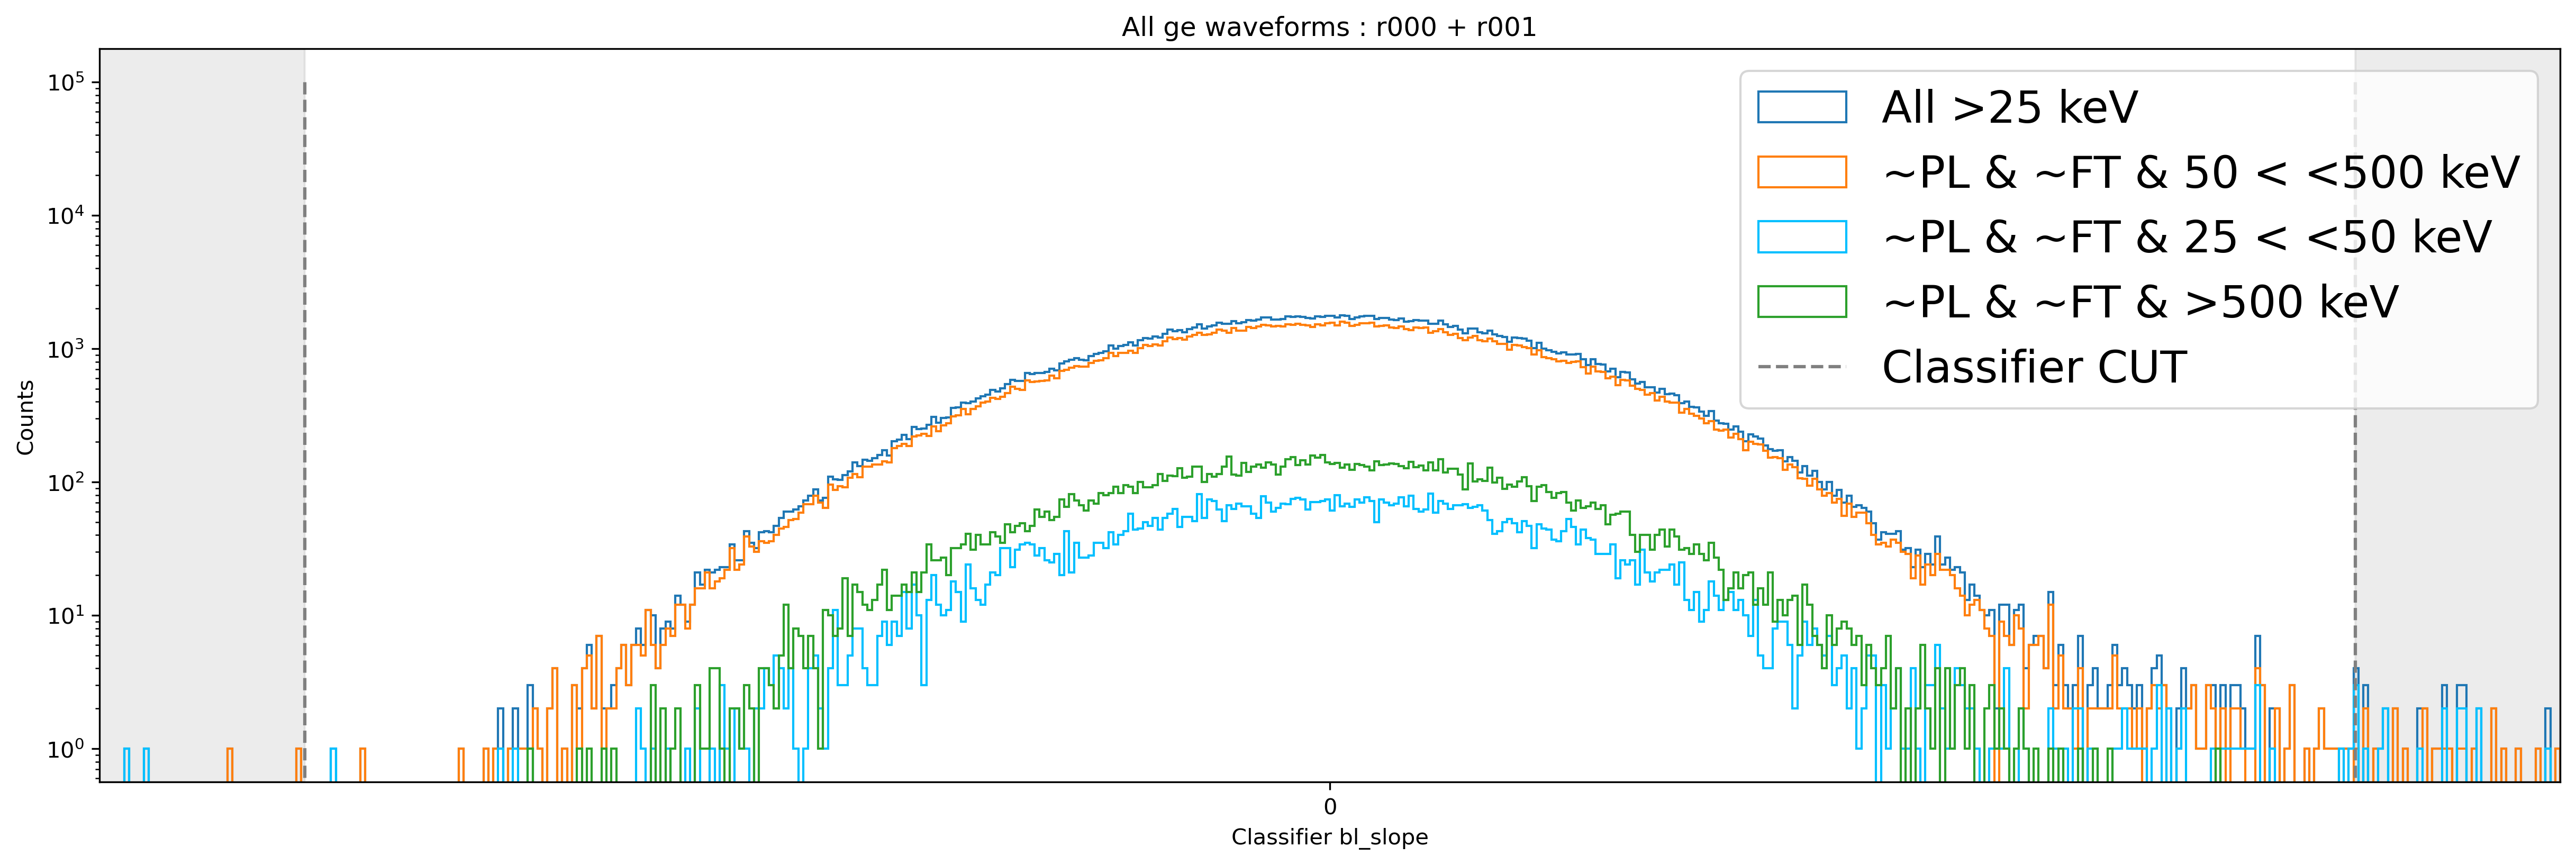

In [48]:
single_plot(df_all,params[0] , title = "All ge waveforms", cmax = 6)

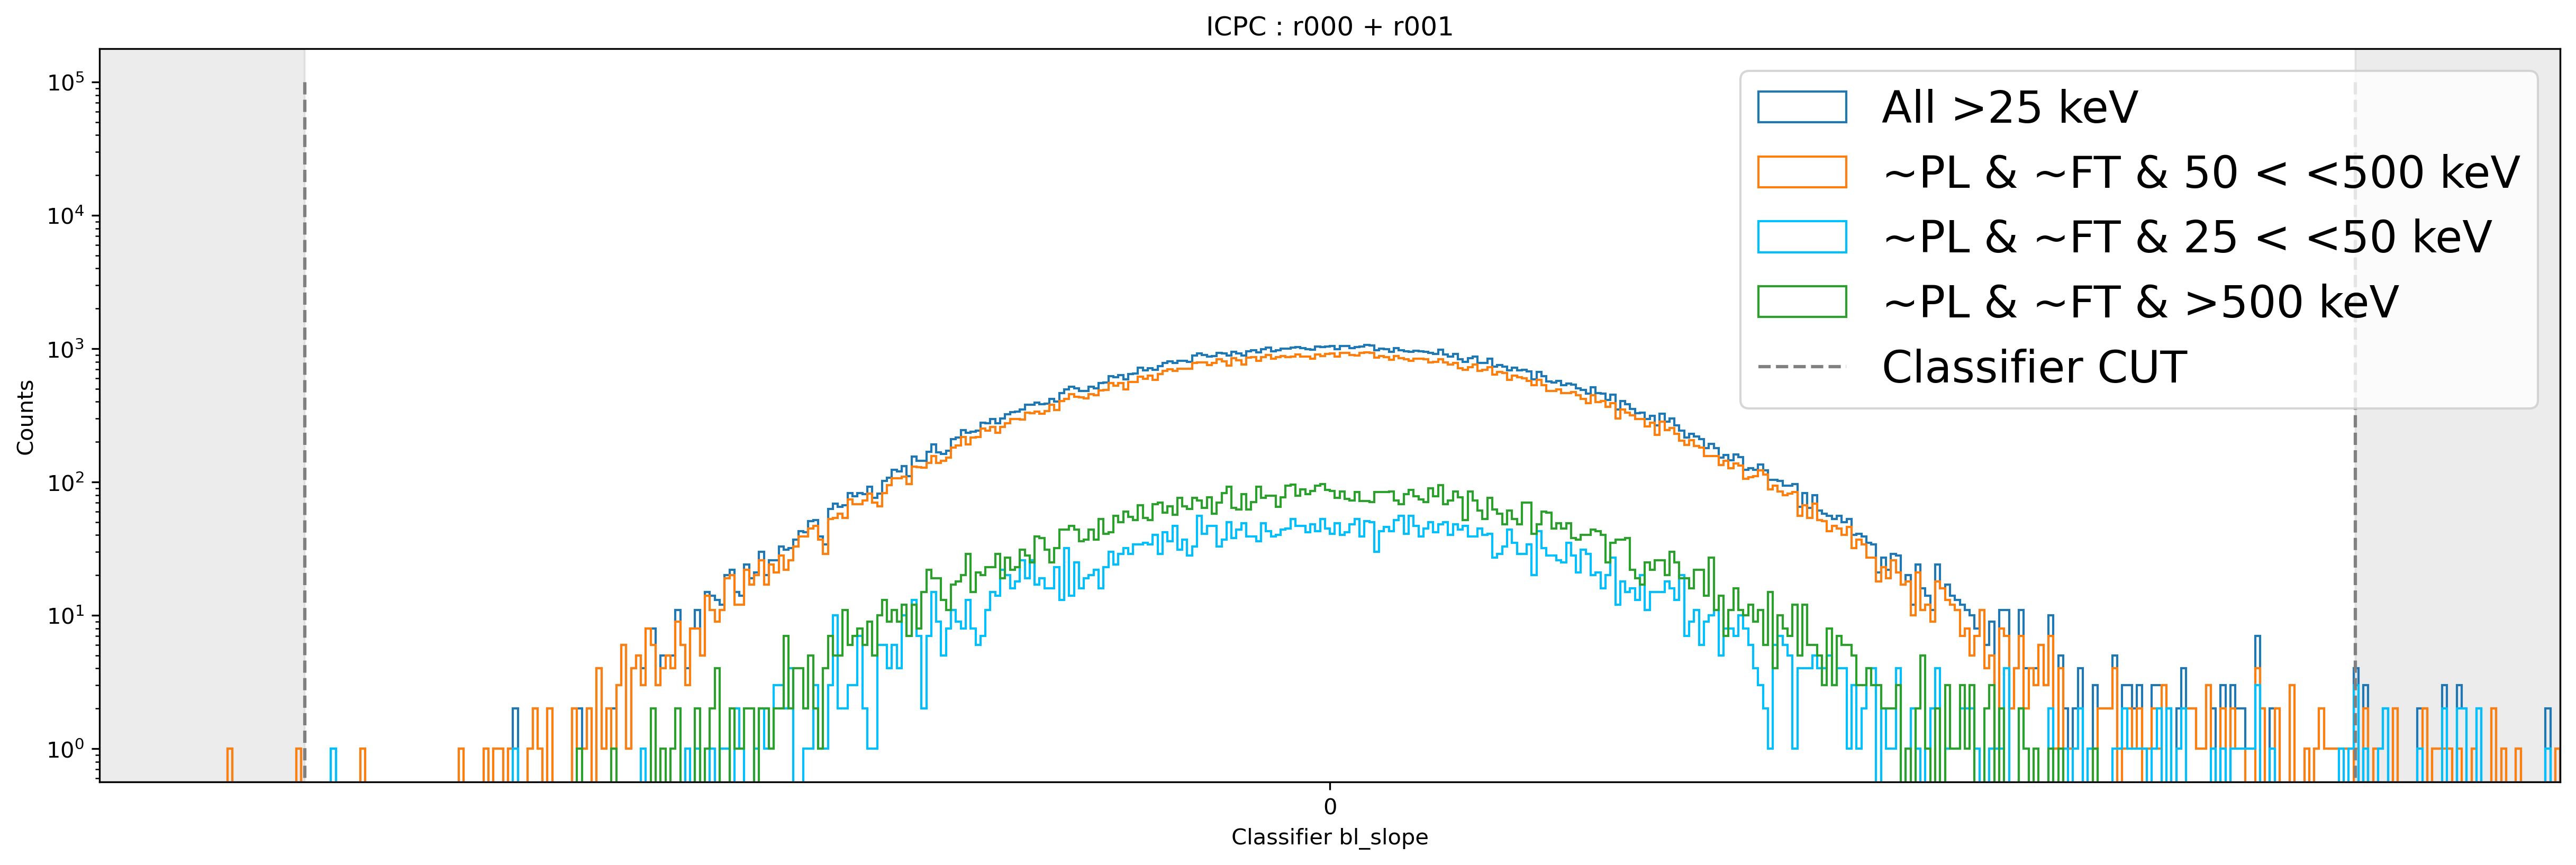

In [49]:
single_plot(df_icpc,params[0] , title = "ICPC", cmax = 6)

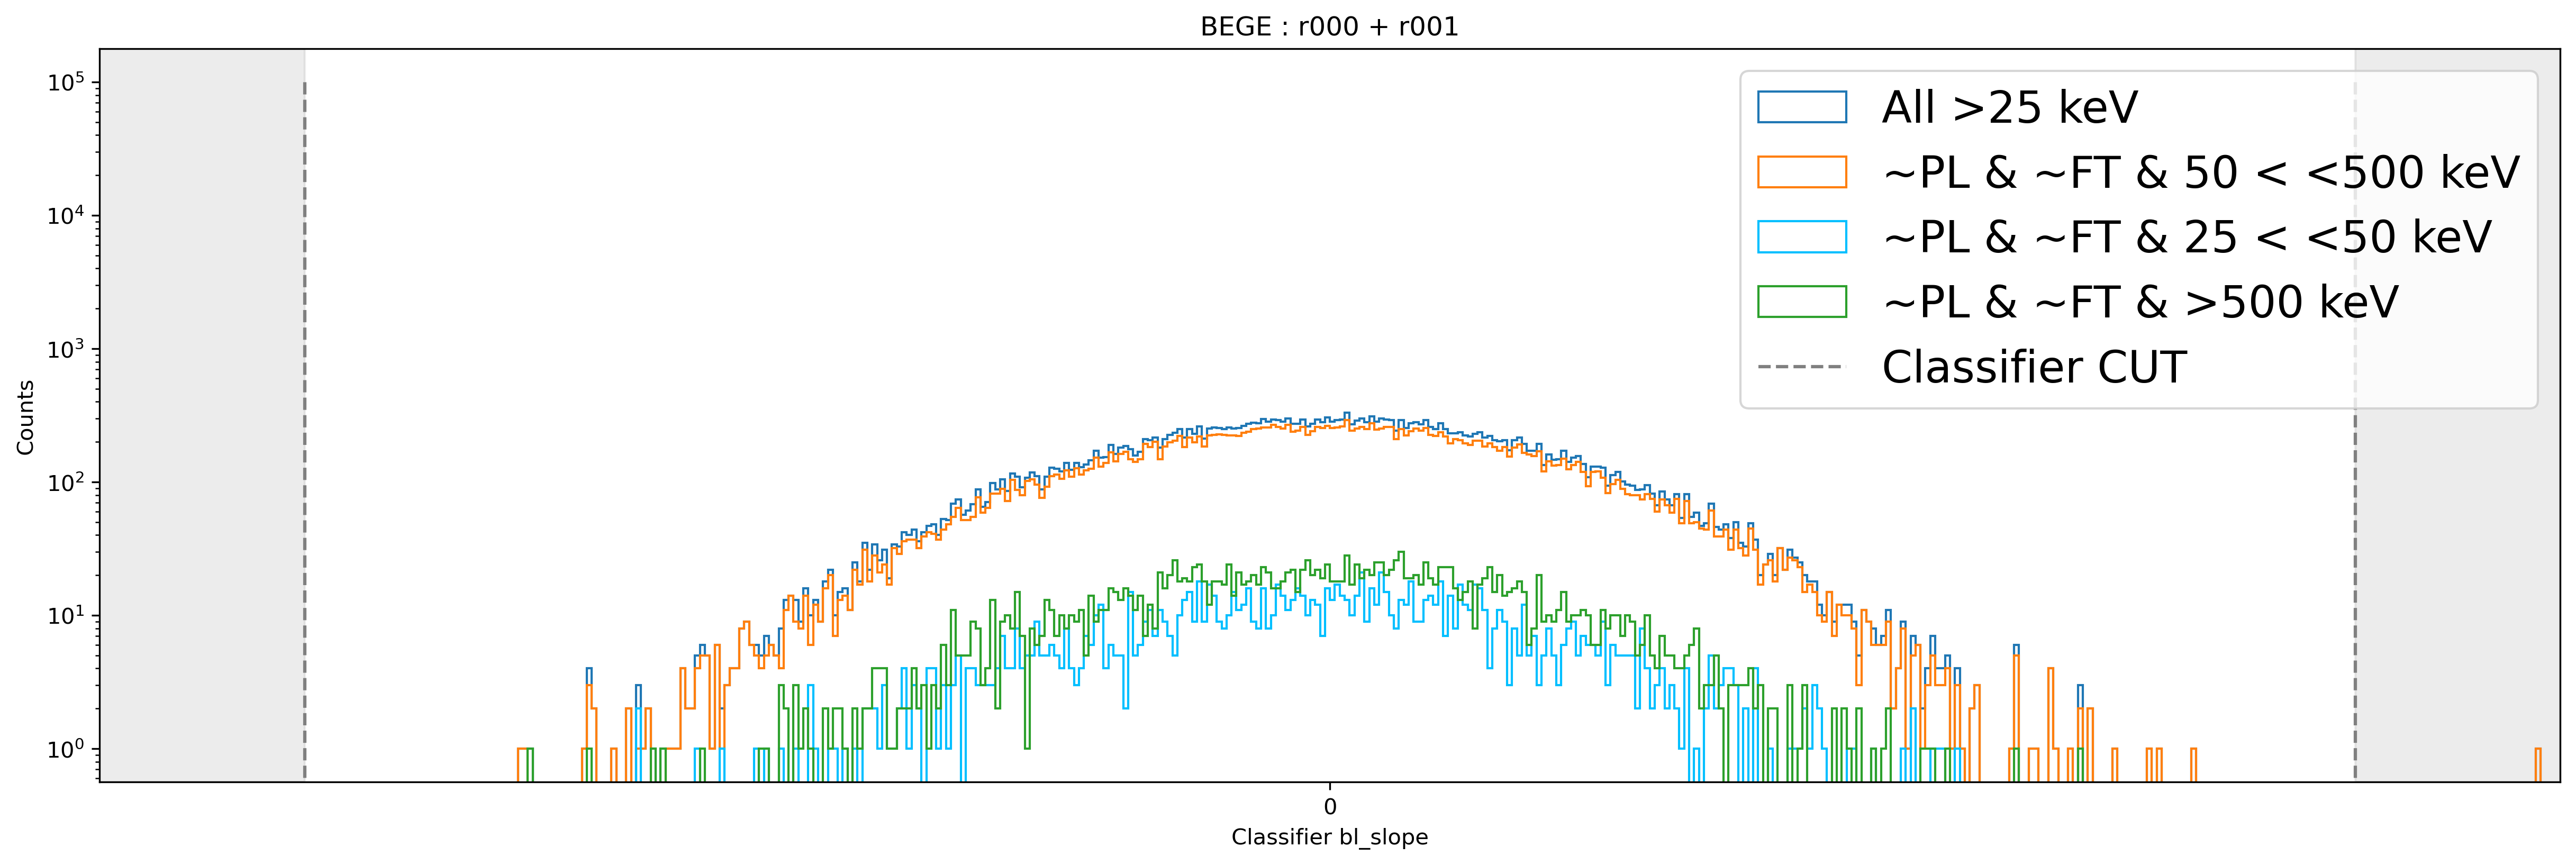

In [50]:
single_plot(df_bege,params[0] , title = "BEGE", cmax = 6)

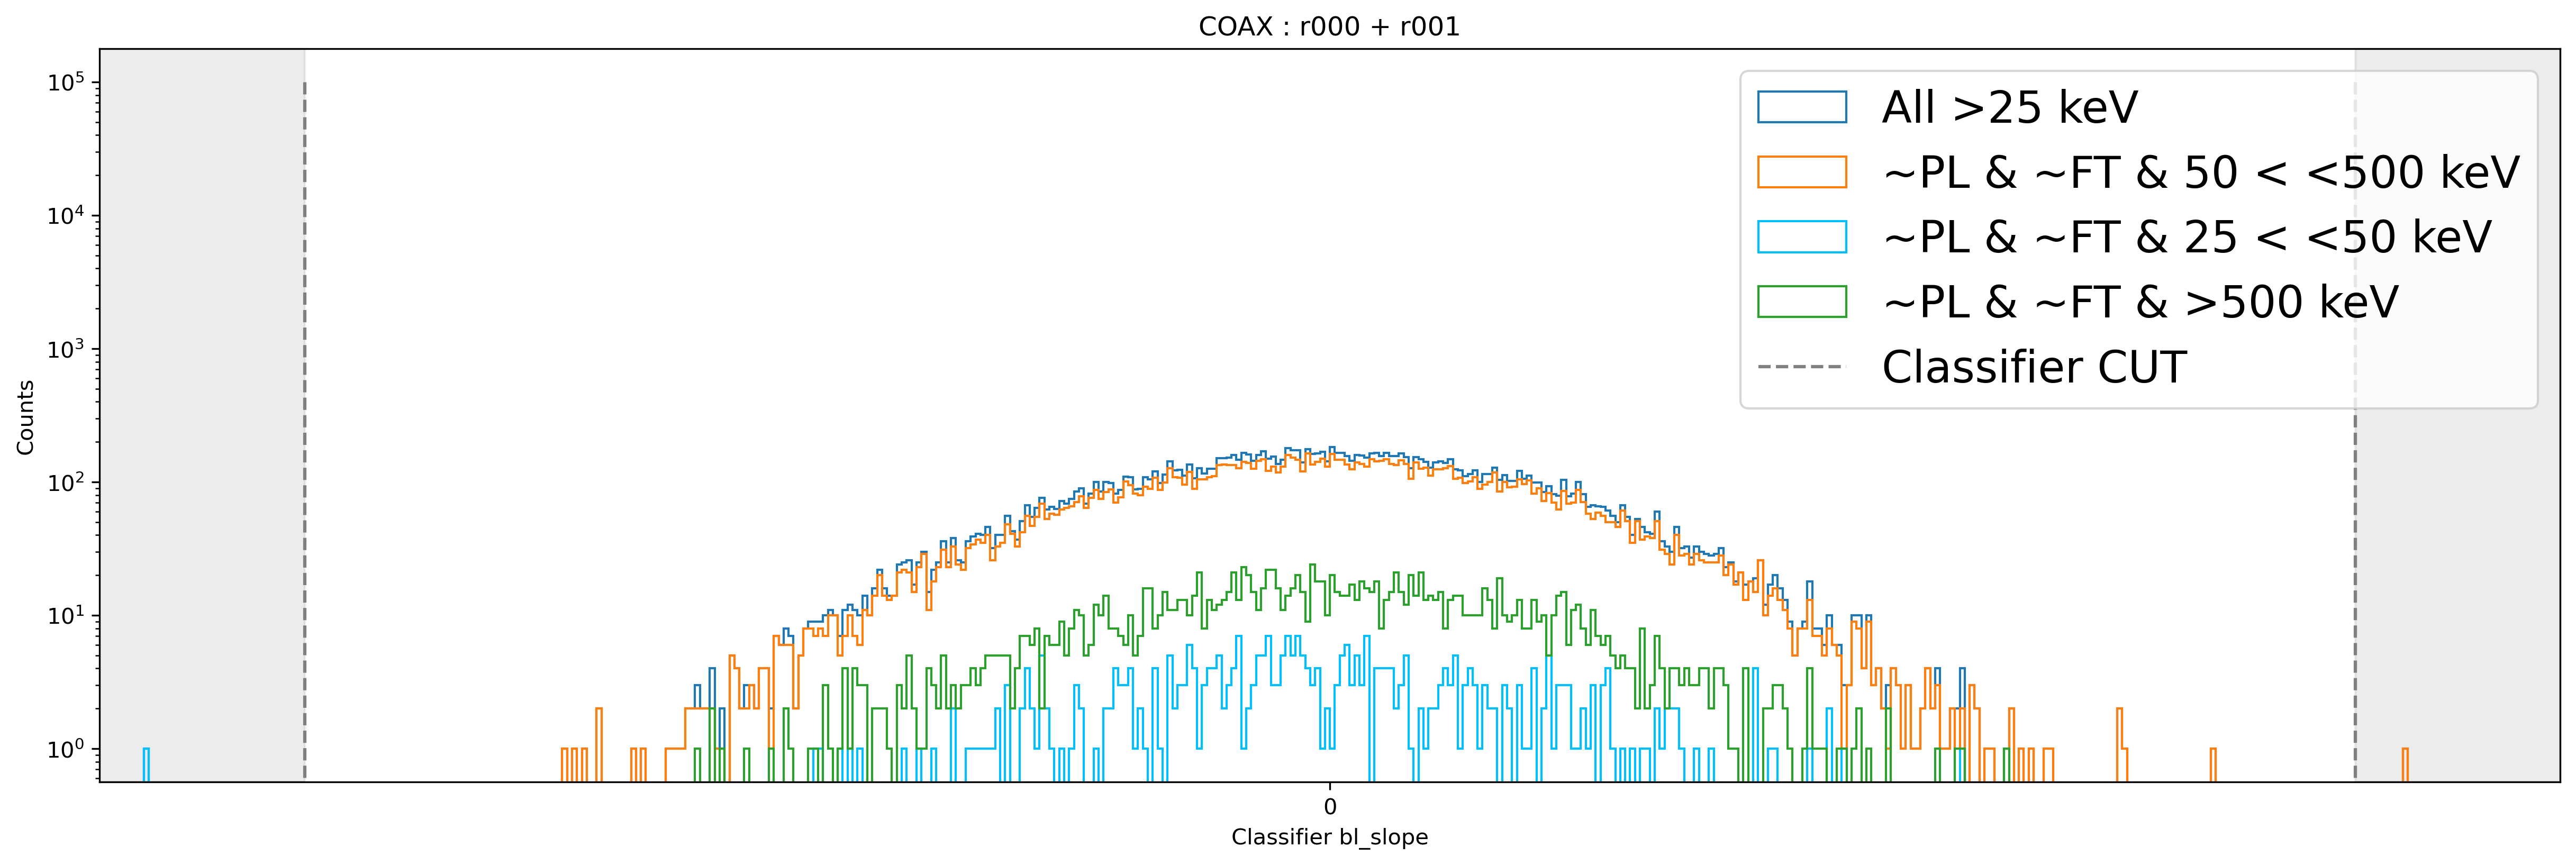

In [51]:
single_plot(df_coax,params[0] , title = "COAX", cmax = 6)

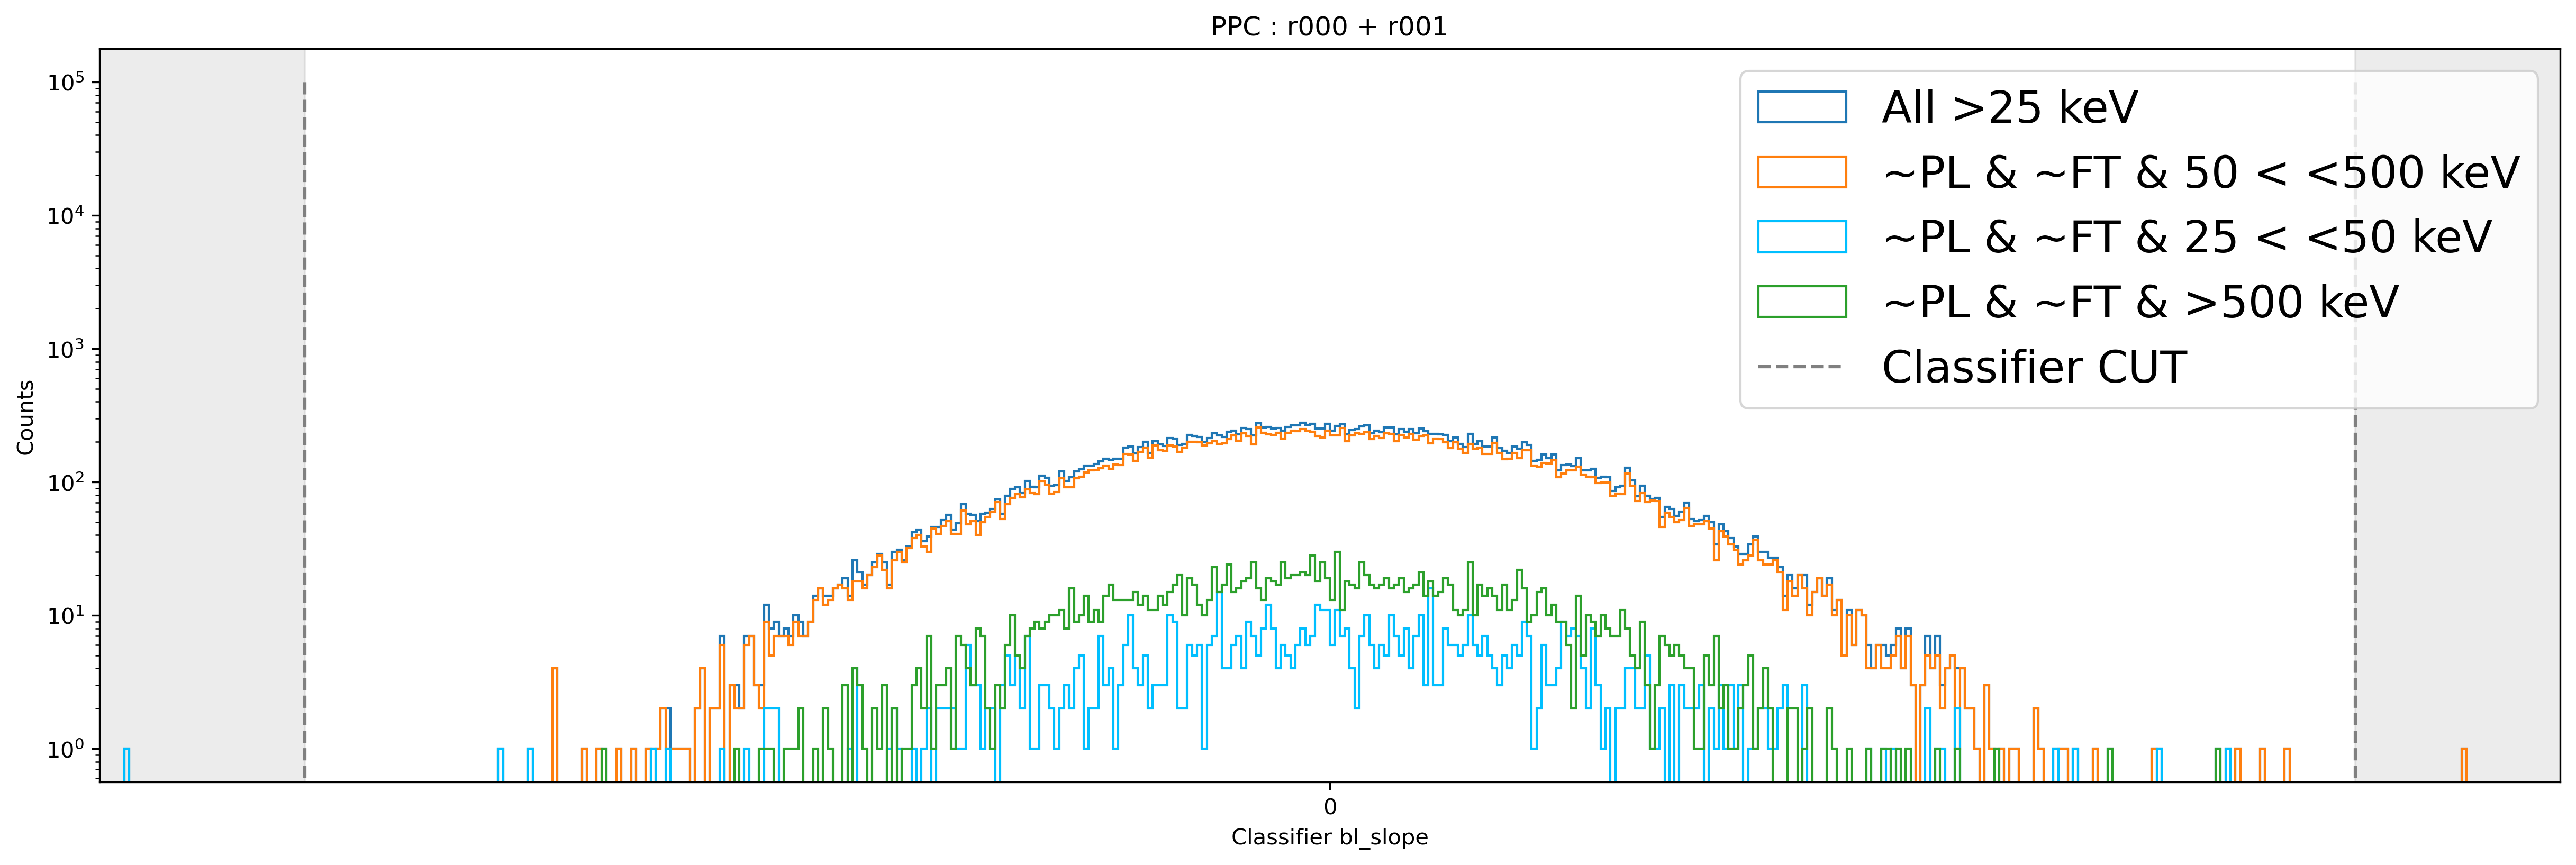

In [52]:
single_plot(df_ppc,params[0] , title = "PPC", cmax = 6)

# bl_slope_rms

# tail_rms

### PLot energy

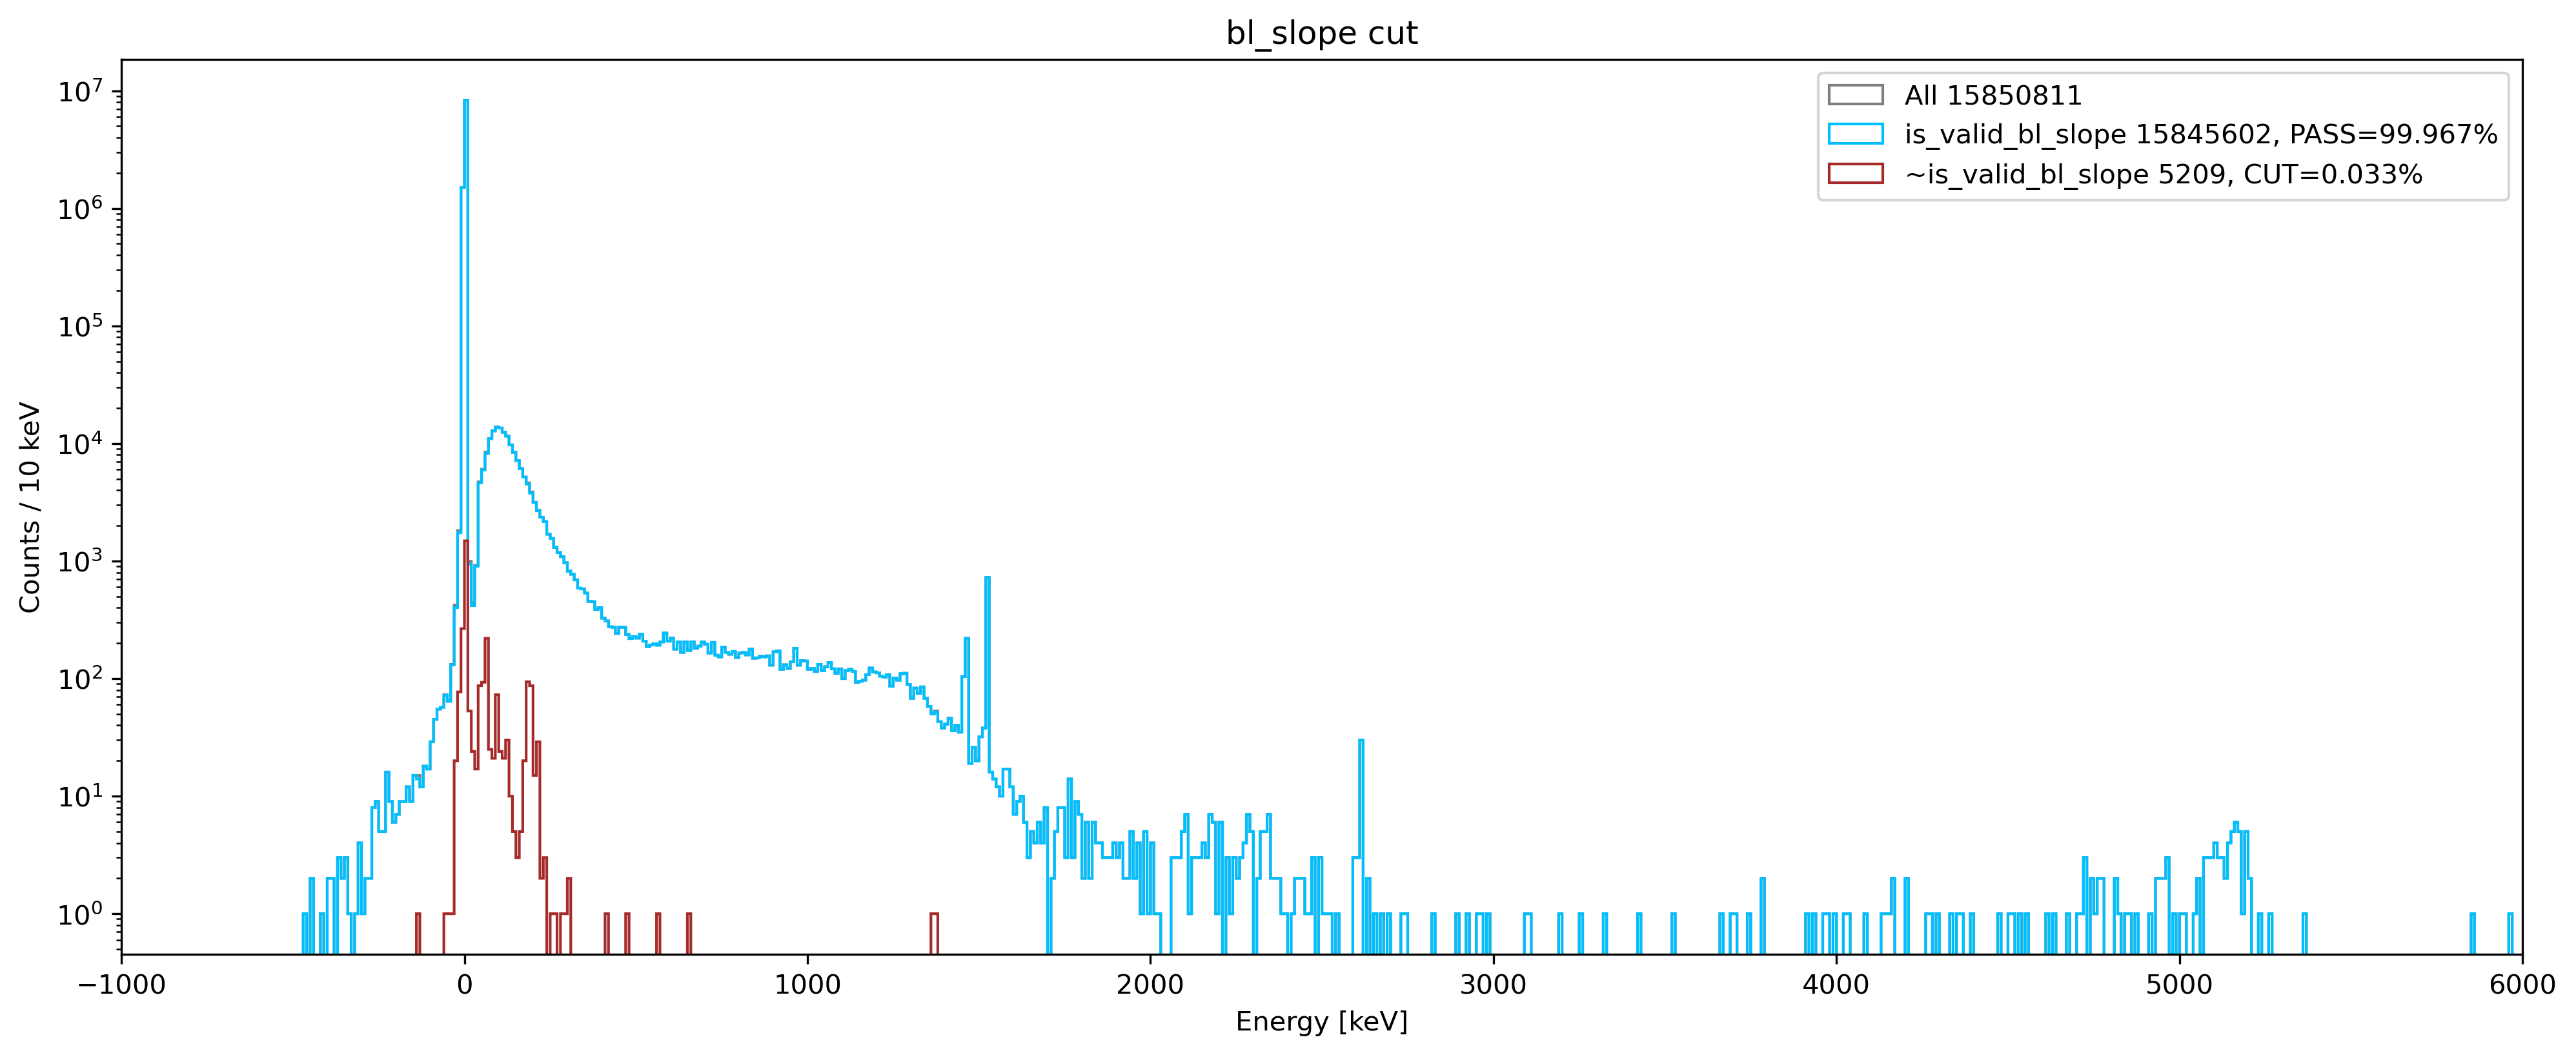

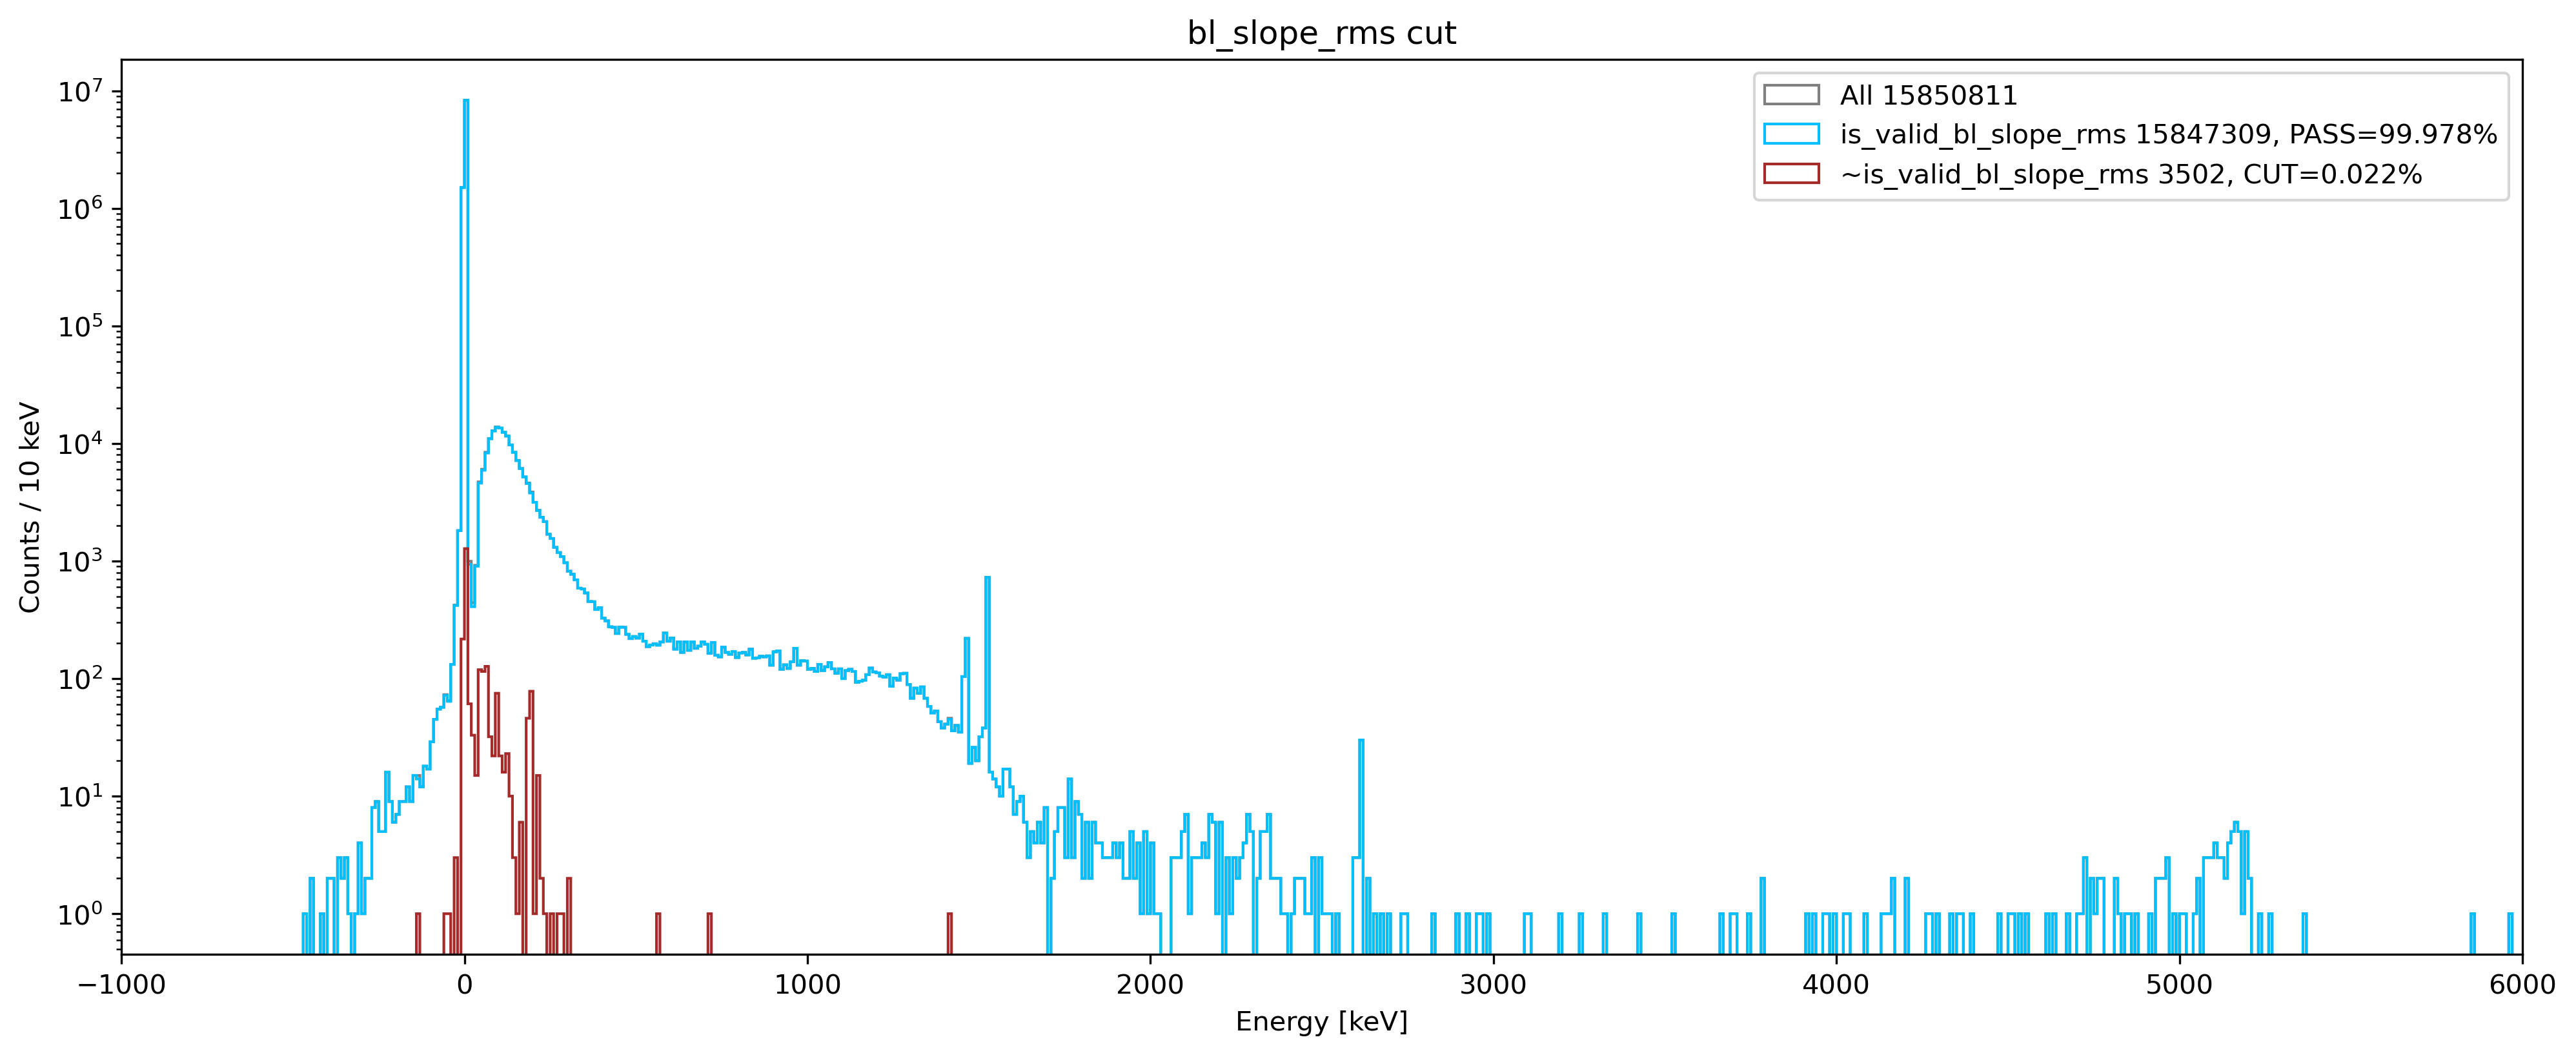

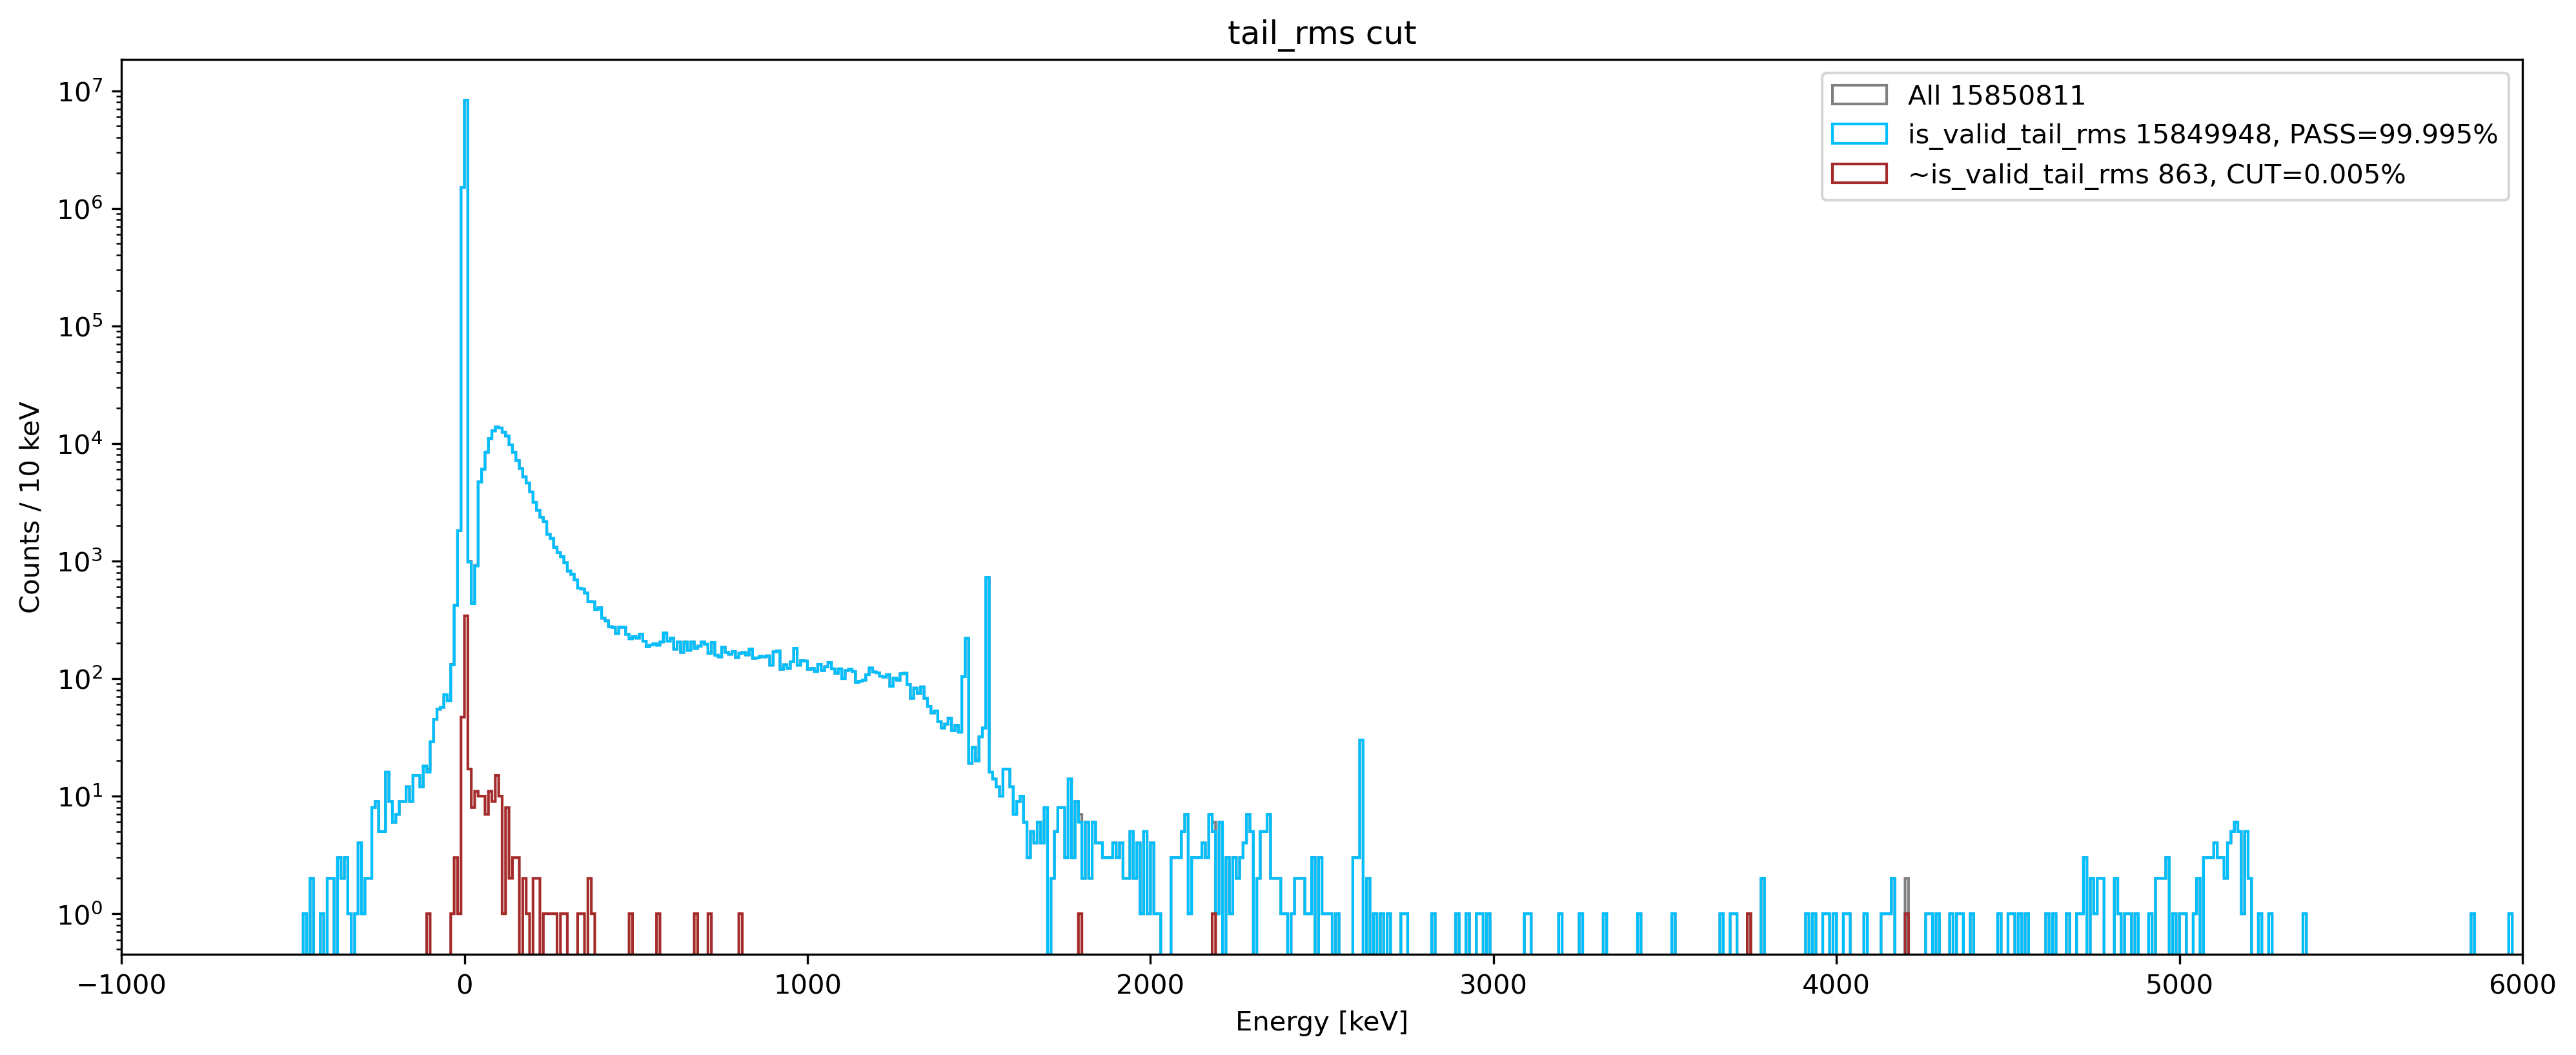

In [53]:

energy_spectrum_cut_plot(df_all, "bl_slope")
energy_spectrum_cut_plot(df_all, "bl_slope_rms")
energy_spectrum_cut_plot(df_all, "tail_rms")